In [1]:
from scipy import sparse
from ase.build import molecule
from ase.neighborlist import natural_cutoffs
from ase.neighborlist import NeighborList
import numpy as np
from ase.io import read
from ase import Atoms
from ase.visualize.plot import plot_atoms
from cell2mol.read_write import readinfo
import nglview
import matplotlib.pyplot as plt

In [2]:
def view_nglview(ase_object):
    view = nglview.show_ase(ase_object)
    view.add_unitcell()
    return view

In [3]:
folder = "error_2"
name = "BOFFOS"
infopath = f"{folder}/{name}/{name}.info"
input_path = f"{folder}/{name}/{name}.cif"

In [4]:
atoms = read(input_path)
cell_labels = atoms.get_chemical_symbols()
cell_pos = atoms.positions
cell_fracs = atoms.get_scaled_positions()
cell_vector = atoms.cell.array
# cell_parameters = atoms.cell.cellpar()
space_group = atoms.info["spacegroup"]
sym_ops = space_group.get_op()

/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 0 and 59 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 0 and 60 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 61 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 62 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 3 and 63 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3

<Axes: >

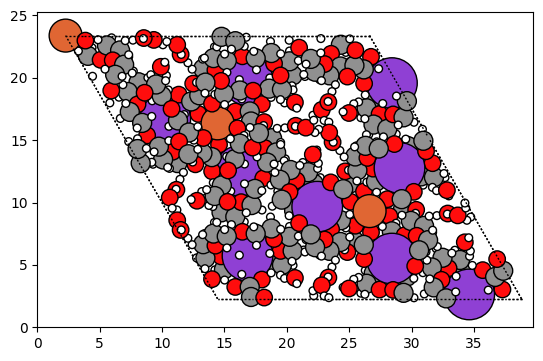

In [6]:
plot_atoms(atoms)

In [7]:
view_nglview(atoms)

NGLWidget()

In [8]:
labels, pos, ref_labels, ref_fracs, cellvec, cell_param = readinfo(infopath)
ref_molecule = Atoms(
    symbols=ref_labels, scaled_positions=ref_fracs, cell=cell_vector, pbc=True
)

<Axes: >

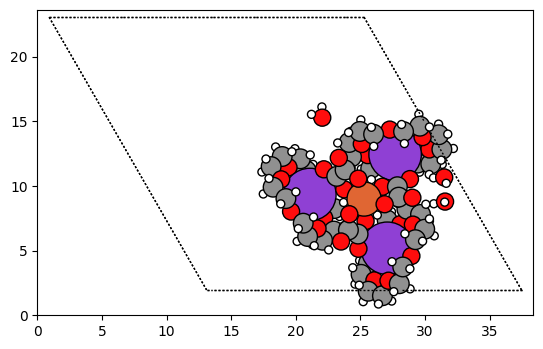

In [9]:
plot_atoms(ref_molecule)

In [10]:
view_nglview(ref_molecule)

NGLWidget()

In [11]:
def apply_symmetry_operations_reference(
    ref_molecule, cell_vector, sym_ops, normalize=True
):
    new_structures = []
    ref_labels = ref_molecule.get_chemical_symbols()
    fractional_coords = ref_molecule.get_scaled_positions()

    for rot, trans in zip(sym_ops[0], sym_ops[1]):
        transformed_positions = np.dot(fractional_coords, rot.T)
        transformed_positions += np.array(trans)
        if normalize:
            transformed_positions = np.remainder(transformed_positions, 1)
        new_molecule = Atoms(
            symbols=ref_labels, scaled_positions=transformed_positions, cell=cell_vector
        )
        new_structures.append(new_molecule)

    return new_structures

In [12]:
new_structures = apply_symmetry_operations_reference(ref_molecule, cell_vector, sym_ops)

In [13]:
new_structures

[Atoms(symbols='C42H78FeK3O33', pbc=False, cell=[[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]]),
 Atoms(symbols='C42H78FeK3O33', pbc=False, cell=[[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]]),
 Atoms(symbols='C42H78FeK3O33', pbc=False, cell=[[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]]),
 Atoms(symbols='C42H78FeK3O33', pbc=False, cell=[[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]]),
 Atoms(symbols='C42H78FeK3O33', pbc=False, cell=[[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]]),
 Atoms(symbols='C42H78FeK3O33', pbc=False, cell=[[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]]),
 Atoms(symbols='C42H78FeK3O33', pbc=False, cell=[[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]]),
 Atoms(symbols='C42H78FeK3O33', pbc=False

<Axes: >

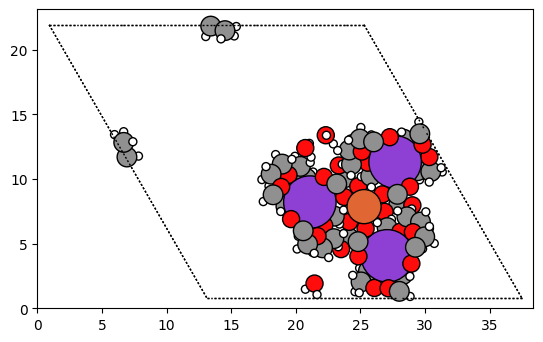

In [33]:
mol = new_structures[1]
plot_atoms(mol)

## check NeighborList

In [16]:
cutoffs = natural_cutoffs(mol)

In [17]:
neighbor_list = NeighborList(cutoffs, self_interaction=False, bothways=True)

In [18]:
neighbor_list.update(mol)

True

In [19]:
matrix = neighbor_list.get_connectivity_matrix()

In [20]:
n_components, component_list = sparse.csgraph.connected_components(matrix)

In [21]:
n_components

24

In [22]:
component_list

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  2,  3,  4,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  5,  6,  7,
        7,  7,  0,  0,  8,  9,  9,  9,  9,  9, 10,  0,  0,  0,  0,  0,  0,
        0,  1,  2,  3,  4, 11,  3,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0, 12, 13, 13, 12,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 14, 15, 16, 17, 18, 19,
       18, 19, 18, 19,  0,  0,  0,  0, 20, 21,  0, 22,  0, 22,  0, 22,  0,
       22, 22,  0, 23,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0, 12, 13], dtype=int32)

In [23]:
idx = 12
molIdx = component_list[idx]
print("There are {} molecules in the system".format(n_components))
print("Atom {} is part of molecule {}".format(idx, molIdx))
molIdxs = [i for i in range(len(component_list)) if component_list[i] == molIdx]
print("Atoms are part of molecule {}: {}".format(molIdx, molIdxs))

There are 24 molecules in the system
Atom 12 is part of molecule 2
Atoms are part of molecule 2: [12, 53]


0 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 36, 37, 45, 46, 47, 48, 49, 50, 51, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 123, 124, 125, 126, 129, 131, 133, 135, 138, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154]
1 [10, 11, 52]
2 [12, 53]
3 [13, 54, 57]
4 [14, 55, 58]
5 [31]
6 [32]
7 [33, 34, 35]
8 [38]
9 [39, 40, 41, 42, 43]
10 [44]
11 [56]
12 [77, 80, 155]
13 [78, 79, 156]
14 [113]
15 [114]
16 [115]
17 [116]
18 [117, 119, 121]
19 [118, 120, 122]
20 [127]
21 [128]
22 [130, 132, 134, 136, 137]
23 [139]


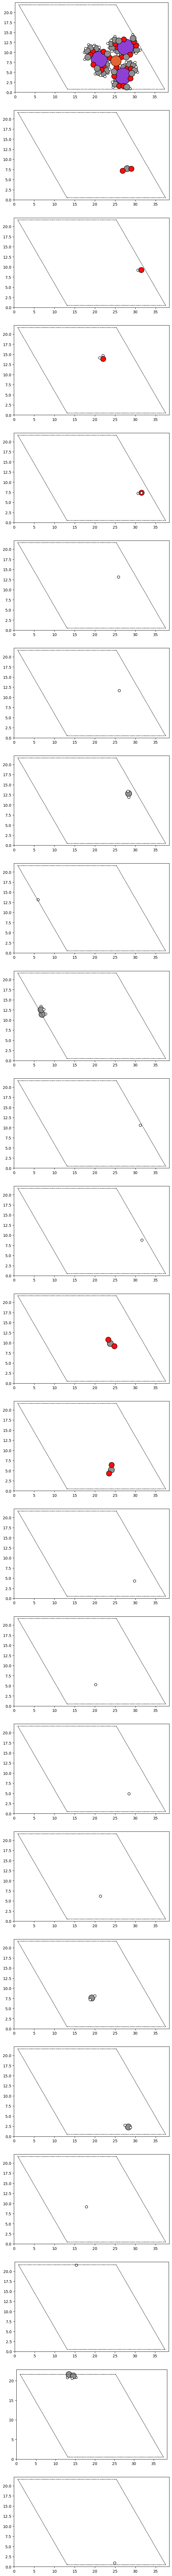

In [24]:
fig, axes = plt.subplots(nrows=n_components, ncols=1, figsize=(20, n_components * 5))
for molIdx, ax in zip(range(n_components), axes):
    molIdxs = [i for i in range(len(component_list)) if component_list[i] == molIdx]
    print(molIdx, molIdxs)
    plot_atoms(mol[molIdxs], ax=ax)

In [25]:
from ase.data import covalent_radii, atomic_numbers
from cell2mol.elementdata import ElementData

elementdatabase = ElementData()

for k, v in atomic_numbers.items():
    if k in elementdatabase.CovalentRadius3.keys():
        if elementdatabase.CovalentRadius3[k] != covalent_radii[v]:
            print(k, elementdatabase.CovalentRadius3[k], covalent_radii[v])

C 0.73 0.76


# Generate newcell

In [20]:
from cell2mol.classes import cell

newcell = cell.from_positional(
    name, cell_labels, cell_pos, cell_fracs, cell_vector, cell_param
)
newcell.get_subtype("unit_cell")

In [21]:
newcell

------------- Cell2mol CELL Object ----------------
 Version               = 2.0
 Type                  = cell
 Sub-Type              = unit_cell
 Name (Refcode)        = BOFFOS
 Num Atoms             = 525
 Cell Parameters a:c   = [24.369, 24.369, 9.748]
 Cell Parameters al:ga = [90.0, 90.0, 120.0]
---------------------------------------------------

In [22]:
debug = 2

In [23]:
newcell.get_reference_molecules(ref_labels, ref_fracs, debug=0)

#########################################
  GETREFS: Generate reference molecules  
#########################################
GETREFS: found 10 reference molecules
GETREFS: ['C6-O12-Fe', 'H24-C12-O6', 'H2-O', 'H2-O', 'H2-O', 'H24-C12-O6', 'H24-C12-O6', 'K', 'K', 'K']
GETREFS: [------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 19
 Formula                      = C6-O12-Fe
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Number of Ligands            = 3
 Number of Metals             = 1
---------------------------------------------------
, ------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 42
 Formula                      = H24-C12-

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 19
  Formula                      = C6-O12-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Number of Ligands            = 3
  Number of Metals             = 1
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 42
  Formula                      = H24-C12-O6
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
 

In [25]:
for ref in newcell.refmoleclist:
    print(ref.parents)

[------------- Cell2mol CELL Object ----------------
 Version               = 2.0
 Type                  = cell
 Sub-Type              = unit_cell
 Name (Refcode)        = BOFFOS
 Num Atoms             = 525
 Cell Parameters a:c   = [24.369, 24.369, 9.748]
 Cell Parameters al:ga = [90.0, 90.0, 120.0]
---------------------------------------------------
 # of Ref Molecules:   = 10
 With Formulae:                                  
    0: C6-O12-Fe 
    1: H24-C12-O6 
    2: H2-O 
    3: H2-O 
    4: H2-O 
    5: H24-C12-O6 
    6: H24-C12-O6 
    7: K 
    8: K 
    9: K 
, ------------- Cell2mol CELL Object ----------------
 Version               = 2.0
 Type                  = cell
 Sub-Type              = reference
 Name (Refcode)        = BOFFOS
 Num Atoms             = 157
 Cell Parameters a:c   = [24.369, 24.369, 9.748]
 Cell Parameters al:ga = [90.0, 90.0, 120.0]
---------------------------------------------------
]
[------------- Cell2mol CELL Object ----------------
 Version      

In [21]:
from new_reconstruction import *

In [26]:
def merge_fragments_test(
    frags: list,
    cell_vector: list,
    cov_factor: float = 1.3,
    metal_factor: float = 1.0,
    debug: int = 0,
):
    # finds biggest fragment and keeps it in the original cell
    sizes = []
    for f in frags:
        size = f.natoms
        sizes.append(size)
    keep_idx = np.argmax(sizes)
    if keep_idx == 0:
        move_idx = 1
    elif keep_idx == 1:
        move_idx = 0
    keep_frag = frags[keep_idx]
    move_frag = frags[move_idx]
    if debug > 0:
        print("MERGE_FRAGMENTS: keep_idx", keep_idx)
    if debug > 0:
        print("MERGE_FRAGMENTS: move_idx", move_idx)

    move_frag.get_centroid()
    move_frag.tmatrix = tmatgenerator(move_frag.frac_centroid)

    if len(move_frag.tmatrix) == 0:
        return None

    for t in move_frag.tmatrix:
        if debug > 0:
            print("MERGE_FRAGMENTS: translation", t)
        ## Applies Translations and each time, it checks if a bigger molecule is formed
        ## meaning that the translation was successful
        reclabels = []
        reclabels.extend(keep_frag.labels)
        reclabels.extend(move_frag.labels)
        reccoord = []
        reccoord.extend(keep_frag.coord)
        if t == (0, 0, 0):
            reccoord.extend(move_frag.coord)
        else:
            reccoord.extend(translate(t, move_frag.coord, cell_vector))
        rec_ref_indices = []
        rec_ref_indices.extend(keep_frag.ref_indices)
        rec_ref_indices.extend(move_frag.ref_indices)

        recfracs = []
        recfracs.extend(keep_frag.frac_coord)
        recfracs.extend(move_frag.frac_coord)

        numspecs = count_species(
            reclabels, reccoord, cov_factor=cov_factor, debug=debug
        )

        if debug > 0:
            print("MERGE_FRAGMENTS: count_species found", numspecs)
        if numspecs != 1:
            continue
        blocklist = split_species(
            reclabels, reccoord, cov_factor=cov_factor, debug=debug
        )
        if blocklist is None:
            continue
        else:
            if len(blocklist) != 1:
                continue
            if len(blocklist) == 1:
                newmolec = molecule.from_positional(reclabels, reccoord, recfracs)
                newmolec.origin = "cell.reconstruct"
                newmolec.ref_indices = rec_ref_indices
                newmolec.set_adjacency_parameters(cov_factor, metal_factor)
                newmolec.set_adj_types()
                newmolec.set_element_count()
                newmolec.get_adjmatrix()
                newmolec.get_centroid()
                newmolec.get_metal_adjmatrix()
                return newmolec
    return None

In [27]:
def fragments_reconstruct_test(
    subset_remaining_fragments, target_ref, cell_vector, debug: int = 0
):
    list_of_found_molecules = []
    final_remaining = subset_remaining_fragments.copy()

    count = 0
    while len(final_remaining) > 0:
        print(
            "final_remaining",
            [k.formula for k in final_remaining],
            [k.subtype for k in final_remaining],
        )

        tobemerged = final_remaining[:2]
        rest = final_remaining[2:]

        print(
            "Fragments TO BE MERGED",
            [k.formula for k in tobemerged],
            [k.subtype for k in tobemerged],
        )
        print("Rest fragments", [k.formula for k in rest], [k.subtype for k in rest])

        found_molecule = []
        bigger_fragment = []
        not_merged = []
        newmolec = merge_fragments_test(tobemerged, cell_vector, debug=debug)

        if newmolec is None:
            print("NOT MERGED", tobemerged[0].formula, tobemerged[1].formula)
            not_merged.append(tobemerged[0])
            not_merged.append(tobemerged[1])

        else:
            print("MERGED", newmolec.formula)
            small_set = set(newmolec.ref_indices)
            print(f"{small_set=}")
            if small_set.issubset(target_ref):
                if sorted(small_set) == target_ref:
                    newmolec.subtype = "molecule"
                    found_molecule.append(newmolec)
                else:
                    newmolec.subtype = "Rec. Fragment"
                    bigger_fragment.append(newmolec)

        print(f"{len(found_molecule)=}")
        print(f"{len(bigger_fragment)=}")
        print(f"{len(not_merged)=}")

        if len(not_merged) == 2:
            final_remaining = []
            final_remaining.append(tobemerged[0])
            final_remaining.extend(rest)
            final_remaining.append(tobemerged[1])

        elif len(found_molecule) == 1:
            list_of_found_molecules.append(newmolec)
            final_remaining = []
            final_remaining.extend(rest)
        elif len(bigger_fragment) == 1:
            final_remaining = []
            final_remaining.append(newmolec)
            final_remaining.extend(rest)

        count += 1

        if len(final_remaining) == 0:
            print(f"{count=}")
            break

    return list_of_found_molecules, final_remaining

In [34]:
from new_reconstruction import *

all_found = []
all_molecules = []
debug = 2
reconstructed_molecules = []
for new in new_structures:
    print("**********")
    found_indices, found_rows = find_row_indices(cell_pos, new.positions)
    print(len(found_indices), len(found_rows))

    updated = [i for i in found_indices if i not in all_found]

    new_fracs = new.get_scaled_positions()
    new_labels = new.get_chemical_symbols()
    indices_in_ref = [
        find_row_index_from_matrix(new_fracs, cell_fracs[u]) for u in updated
    ]
    # print(f"{indices_in_ref=}")
    all_found.extend(updated)
    print(len(all_found))
    print(len(all_found) == len(cell_pos))  # If Ture, stop

    # #### make blocks and get fragments ####
    fragments = get_fragments(newcell, updated, indices_in_ref, debug=0)
    molecules, remaining_fragments = classify_fragments(fragments, newcell, debug=0)
    all_molecules.extend(molecules)

    # Grouping remaining fragments for reconstruction
    grouped_lists = [[] for _ in range(len(newcell.refmoleclist))]

    for i, ref in enumerate(newcell.refmoleclist):
        target_set = set(ref.get_parent_indices("refcell"))
        for j, rem_frag in enumerate(remaining_fragments):
            small_set = set(rem_frag.ref_indices)
            if small_set.issubset(target_set):
                # if debug >=1 : print(f"{j} {rem_frag.formula} is a subset of target_set {i} {ref.formula}")
                grouped_lists[i].append(rem_frag)

    for i, group in enumerate(grouped_lists):
        if len(group) > 0:
            # group[0] : a biggest fragment within the group

            # dist = np.array([get_dist(rem.frac_centroid, [0.5, 0.5, 0.5]) for rem in group])
            # dist = np.array([get_dist(rem.frac_centroid, group[0].frac_centroid) for rem in group])
            # dist = np.array([get_dist(rem.centroid, group[0].centroid) for rem in group])

            # dist = np.array([get_dist(rem.frac_centroid, [0.5, 0.5, 0.5]) for rem in group])
            # sorted_group = [ group[k] for k in np.argsort(dist) ]

            # fig, axes = plt.subplots(nrows=len(dist), ncols=1, figsize=(10, len(dist)*5))

            # for k, ax in zip(np.argsort(dist), axes):
            #     rem = group[k]
            #     distance = dist[k]
            #     plot_atoms(Atoms(symbols=rem.labels, scaled_positions=rem.frac_coord, cell=cell_vector, pbc=True), ax=ax)
            #     ax.set_title(f"{i} {newcell.refmoleclist[i].formula} / {rem.formula} ({distance})")

            if debug >= 1:
                print(f"target_ref: {newcell.refmoleclist[i].formula}")
                print(f"Group {i}: {[rem.formula for rem in group]}")
                # print("Remaining_fragments unit cell center:", [get_dist(rem.frac_centroid, [0.5, 0.5, 0.5]) for rem in group])
                # print("Remaining_fragments frac_centroid:", [get_dist(rem.frac_centroid, group[0].frac_centroid) for rem in group])
                # print("Remaining_fragments centroid:", [get_dist(rem.centroid, group[0].centroid) for rem in group])

            target_ref = newcell.refmoleclist[i].get_parent_indices("refcell")
            list_of_found_molecules, final_remaining = fragments_reconstruct_test(
                group, target_ref, cell_vector, debug=0
            )
            print(f"{list_of_found_molecules=}")
            reconstructed_molecules.extend(list_of_found_molecules)
            # TODO : get charge, spin, bond, rdkit information from reference

            if len(final_remaining) > 0:
                Warning = True
            elif len(final_remaining) == 0:
                Warning = False

    # smaller_lists = [rem_frag.ref_indices for rem_frag in remaining_fragments]

    # target_sets = [set(ref.get_parent_indices("cell")) for ref in newcell.refmoleclist]

    # print(f"{smaller_lists=}")
    # print(f"{target_sets=}")
    # for i, target_set in enumerate(target_sets):
    #     for j, small_list in enumerate(smaller_lists):
    #         small_set = set(small_list)
    #         if small_set.issubset(target_set):
    #             if debug >=1 : print(f"{j} {small_set} is a subset of target_set {target_set} {newcell.refmoleclist[i].formula}")

    # grouped_rem_frags, indices_of_rem_frags, target_idx_lists = grouping_smaller_lists_for_target_sets(target_sets, smaller_lists, debug=0)
    # print(f"{indices_of_rem_frags=}")
    # print(f"{target_idx_lists=}")
    # smaller_lists.sort(key=len, reverse=True)
    # print(f"{smaller_lists=}")

    # grouped_rem_frags, indices_from_rem_frags, indices_of_target_ref = grouping_remaining_fragments(remaining_fragments, not_found_list, newcell, debug=debug)
    # print(f"{grouped_rem_frags=} {indices_from_rem_frags=}")
    # all_found_molecules = []
    # for indices, target_ref in zip(indices_from_rem_frags, indices_of_target_ref):
    #     subset_remaining_fragments = [ remaining_fragments[idx] for idx in indices]
    #     list_of_found_molecules, final_remaining = find_molecule_from_subset_rem_frags(subset_remaining_fragments, target_ref, cell_vector, debug=0)
    #     reconstructed_molecules.extend(list_of_found_molecules)

    #     if len(final_remaining) > 0 :
    #         Warning = True
    #     elif len(final_remaining) == 0 :
    #         Warning = False
    # if len(all_found) == 157:

    if len(all_found) == len(cell_pos):
        break
# all_molecules.extend(reconstructed_molecules)

**********
157 157
157
False


TypeError: 'NoneType' object is not iterable

In [ ]:
all_molecules

In [73]:
combined_mol = Atoms(cell=cell_vector, pbc=True)
for k in all_molecules:
    print(k.formula)
    mol = Atoms(symbols=k.labels, positions=k.coord, cell=cell_vector, pbc=True)
    combined_mol += mol

H2-O
H2-O
K
K
K
H2-O
H2-O
H2-O
H2-O
C6-O12-Fe
H2-O
H2-O
K
K
K
H2-O
H2-O
H2-O
H2-O
H2-O
H2-O
H2-O
K
K
K
H2-O
H2-O
H2-O
H2-O
H2-O


In [75]:
for k in reconstructed_molecules:
    print(k.formula)
    mol = Atoms(symbols=k.labels, positions=k.coord, cell=cell_vector, pbc=True)
    combined_mol += mol

C6-O12-Fe
H24-C12-O6
H2-O
H24-C12-O6
H24-C12-O6
H2-O
H2-O
H24-C12-O6
H2-O
H24-C12-O6
H24-C12-O6
H2-O
C6-O12-Fe
H24-C12-O6
H2-O
H24-C12-O6
H24-C12-O6
H2-O


In [76]:
view_nglview(combined_mol)

NGLWidget()

In [77]:
combined_mol.write(f"{folder}/{name}/reconstructed_positions_{name}.xyz")

In [78]:
final_remaining

[]